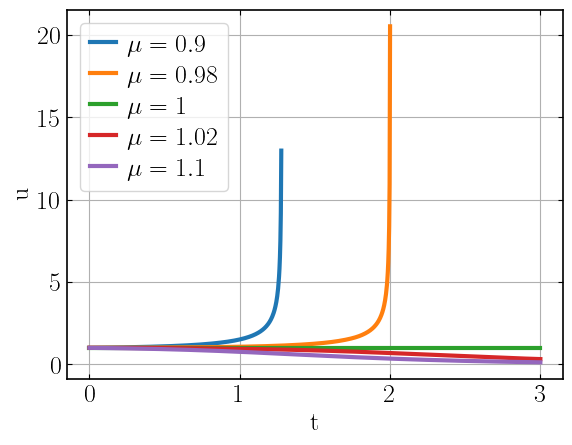

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


plt.rcParams.update({
    "font.size": 13,
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{lmodern}",
    "font.family": "serif",

    'legend.fontsize': 'x-large',
    'axes.labelsize': 'x-large',
    'axes.titlesize':'xx-large',
    'xtick.labelsize':'x-large',
    'ytick.labelsize':'x-large',
    'lines.linewidth': 3,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})

mu = [ 0.9, 0.98, 1, 1.02, 1.1]

# Funzione generatrice dell'ODE parametrica
def make_ode(mu_value):
    return lambda t, y: -mu_value*y+y**3

# Intervallo e condizioni iniziali
t_span = (0, 3)
y0 = [1]

# Risoluzione per ciascun valore di mu
sol = []
for m in mu:
    ode_func = make_ode(m)
    s = solve_ivp(ode_func, t_span, y0, t_eval=np.linspace(t_span[0], t_span[1], 1000))
    sol.append((m, s))

fig, ax = plt.subplots()

# Plotting
for m, s in sol:
    ax.plot(s.t, s.y[0], label=fr"$\mu={m}$")

ax.set_xlabel("t")
ax.set_ylabel("u")
ax.grid(True)
ax.legend(
    loc='upper left', 
    ncol=1,
    handlelength=1.0,
    handletextpad=0.4,
    labelspacing=0.3
)
fig.savefig(f"plots/Pitchfork_solutions_1.pdf",bbox_inches="tight")